# SNGP: Spectral-Normalized Neural Gaussian Process

Single forward pass distance-aware uncertainty.

SNGP combines two techniques to achieve calibrated uncertainty in a single forward pass:

1. **Spectral Normalization** on hidden layers preserves distances in feature space -- inputs that are far apart in input space remain far apart in the learned representation. This prevents "feature collapse" where OOD inputs get mapped near training data.

2. **Random Fourier Features (RFF)** in the last layer approximate a Gaussian Process kernel, providing a closed-form predictive variance that scales with distance from training data.

The result is a model that is confident on in-distribution inputs and appropriately uncertain both near decision boundaries and far from all training data -- without requiring multiple forward passes or sampling.

**Reference:** Liu et al., "Simple and Principled Uncertainty Estimation with Deterministic Deep Learning via Distance Awareness" (NeurIPS 2020)

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from deepuq.models import MLP
from deepuq.methods.sngp import SNGPWrapper

## Generate 2-Class Spiral Data

The spiral dataset is an excellent test for uncertainty methods because:
- The **decision boundary** is complex and nonlinear, so the model should be uncertain near it.
- There are large **regions far from all data** where the model has no information and should express high uncertainty.
- A standard softmax classifier will be overconfident everywhere; SNGP should correctly flag both boundary and far-field regions.

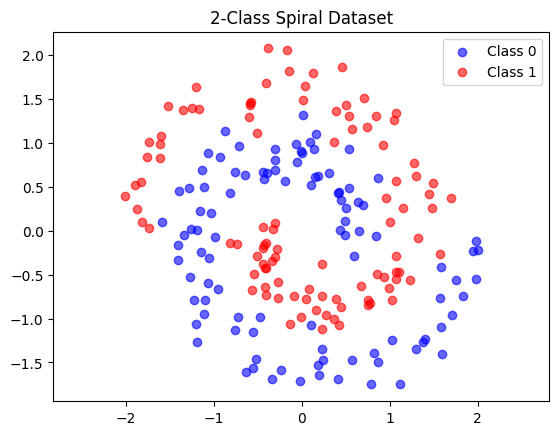

In [2]:
np.random.seed(42)

def make_spiral(n_points=100, noise=0.2):
    """Generate 2-class spiral dataset."""
    theta = np.linspace(0, 2 * np.pi, n_points)
    r = np.linspace(0.5, 2, n_points)
    
    # Class 0
    x0 = r * np.cos(theta) + noise * np.random.randn(n_points)
    y0 = r * np.sin(theta) + noise * np.random.randn(n_points)
    
    # Class 1 (rotated by pi)
    x1 = r * np.cos(theta + np.pi) + noise * np.random.randn(n_points)
    y1 = r * np.sin(theta + np.pi) + noise * np.random.randn(n_points)
    
    X = np.vstack([np.column_stack([x0, y0]), np.column_stack([x1, y1])])
    y = np.array([0]*n_points + [1]*n_points)
    return X, y

X_train, y_train = make_spiral(100, noise=0.2)
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)

plt.scatter(X_train[:100, 0], X_train[:100, 1], c='blue', alpha=0.6, label='Class 0')
plt.scatter(X_train[100:, 0], X_train[100:, 1], c='red', alpha=0.6, label='Class 1')
plt.legend()
plt.title('2-Class Spiral Dataset')
plt.axis('equal')
plt.show()

## Create and Train SNGP Model

The SNGP training loop has a key difference from standard training: we must **reset the precision matrix** (inverse covariance) at the start of each epoch and **update it** after each forward pass. This maintains the GP posterior's precision matrix as a running sum of outer products of random features, analogous to Bayesian linear regression in the RFF space.

The spectral normalization (controlled by `spec_norm_bound`) is applied automatically to hidden layers, bounding the Lipschitz constant and ensuring distance preservation.

In [3]:
import torch.nn as nn

# MLP uses nn.Sequential internally with no named last layer.
# Define a custom model with a named 'output' layer for SNGP.
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.hidden = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU()
        )
        self.output = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        return self.output(self.hidden(x))

# Create base model and wrap with SNGP
base_model = SimpleMLP(input_dim=2, hidden_dim=64, output_dim=2)
sngp_model = SNGPWrapper(base_model, last_layer_name='output', num_random_features=512, spec_norm_bound=6.0)

optimizer = torch.optim.Adam(sngp_model.parameters(), lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

# Training loop
sngp_model.train()
for epoch in range(100):
    # Reset covariance at start of epoch
    sngp_model.reset_covariance()
    
    optimizer.zero_grad()
    logits = sngp_model(X_train_t)
    loss = loss_fn(logits, y_train_t)
    loss.backward()
    optimizer.step()
    
    # Update covariance with training data
    sngp_model.update_covariance(X_train_t)
    
    if (epoch + 1) % 25 == 0:
        acc = (logits.argmax(dim=1) == y_train_t).float().mean()
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}, Acc: {acc.item():.3f}")

Epoch 25, Loss: 0.6580, Acc: 0.515
Epoch 50, Loss: 0.6203, Acc: 0.515
Epoch 75, Loss: 0.5822, Acc: 0.640
Epoch 100, Loss: 0.5505, Acc: 0.710


## Predict with Uncertainty

At test time, SNGP computes predictive variance from the GP posterior in a single forward pass. The variance at a test point $x^*$ is:

$$\text{Var}(x^*) = \phi(x^*)^\top \Sigma \phi(x^*)$$

where $\phi(x^*)$ is the random feature representation and $\Sigma$ is the posterior covariance. Points far from training data have feature vectors that are not "explained" by the precision matrix, yielding high variance.

In [4]:
# Create grid of test points
xx = np.linspace(-4, 4, 80)
yy = np.linspace(-4, 4, 80)
XX, YY = np.meshgrid(xx, yy)
grid_points = torch.FloatTensor(np.column_stack([XX.ravel(), YY.ravel()]))

# Predict
sngp_model.eval()
result = sngp_model.predict_uq(grid_points)

probs = result.probs.numpy()  # (N, 2)
epistemic_var = result.epistemic_var.numpy()  # (N, 2)

print(f"Prediction shape: {probs.shape}")
print(f"Uncertainty shape: {epistemic_var.shape}")
print(f"Method: {result.metadata['method']}")

Prediction shape: (6400, 2)
Uncertainty shape: (6400, 2)
Method: sngp


## Visualize Decision Boundary with Uncertainty

The uncertainty heatmap reveals two sources of predictive uncertainty:
- **Near the decision boundary**: the model is uncertain about which class a point belongs to.
- **Far from all training data**: the model recognizes it has no information and expresses high epistemic uncertainty.

This "distance-aware" property is what distinguishes SNGP from standard neural networks, which tend to be overconfident on OOD inputs.

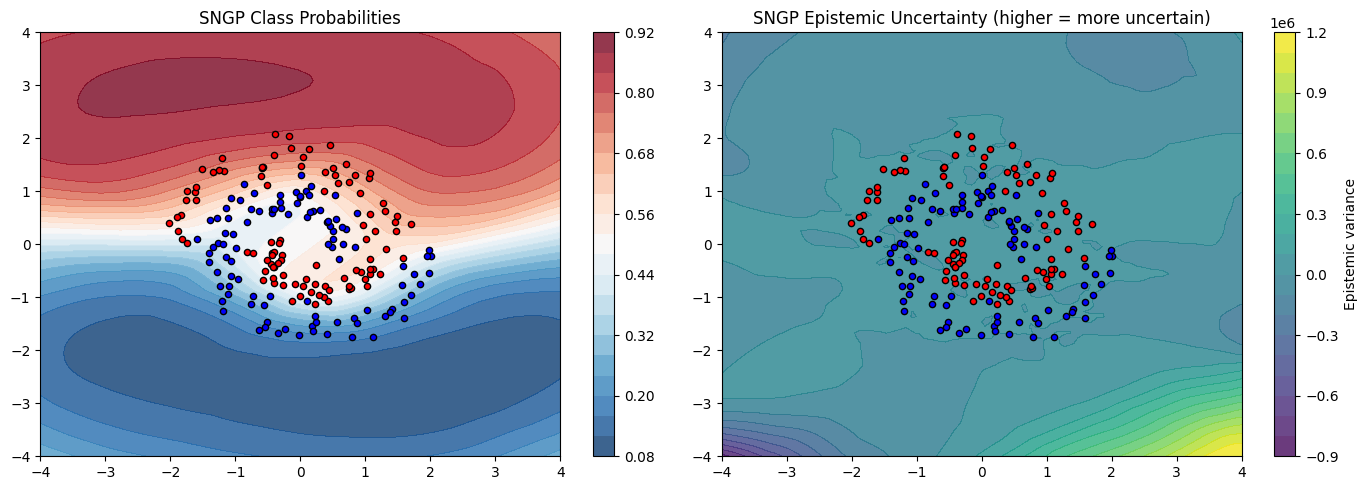

Note: Uncertainty is higher far from training data, demonstrating
SNGP's distance-aware uncertainty estimation.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Decision boundary (class 1 probability)
prob_grid = probs[:, 1].reshape(80, 80)
ax = axes[0]
c = ax.contourf(XX, YY, prob_grid, levels=20, cmap='RdBu_r', alpha=0.8)
ax.scatter(X_train[:100, 0], X_train[:100, 1], c='blue', edgecolors='k', s=20)
ax.scatter(X_train[100:, 0], X_train[100:, 1], c='red', edgecolors='k', s=20)
ax.set_title('SNGP Class Probabilities')
plt.colorbar(c, ax=ax)

# Epistemic uncertainty (mean across classes)
unc_grid = epistemic_var.mean(axis=1).reshape(80, 80)
ax = axes[1]
c = ax.contourf(XX, YY, unc_grid, levels=20, cmap='viridis', alpha=0.8)
ax.scatter(X_train[:100, 0], X_train[:100, 1], c='blue', edgecolors='k', s=20)
ax.scatter(X_train[100:, 0], X_train[100:, 1], c='red', edgecolors='k', s=20)
ax.set_title('SNGP Epistemic Uncertainty (higher = more uncertain)')
plt.colorbar(c, ax=ax, label='Epistemic variance')

plt.tight_layout()
plt.show()

print("Note: Uncertainty is higher far from training data, demonstrating")
print("SNGP's distance-aware uncertainty estimation.")